In [3]:
import geopandas as gpd
import rasterio
from pathlib import Path

IMAGES_DIR = Path("/home/samuel/test/MasterThesis/Orthomosaics/translated/small/translated_n18x/processed_output/image_tiles")
SHAPES_DIR = Path("/home/samuel/test/MasterThesis/Orthomosaics/translated/small/translated_n18x/shapes")
OUTPUT_DIR = Path("/home/samuel/test/MasterThesis/Orthomosaics/translated/small/translated_n18x/labels_txt")

CLASS_FIELD = "class_id"  # change if needed

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def polygon_to_yolo(row, raster_bounds, px_w, px_h, img_w, img_h):
    geom = row.geometry
    minx, miny, maxx, maxy = geom.bounds

    # center in map units
    x_center = (minx + maxx) / 2
    y_center = (miny + maxy) / 2

    # convert to pixel coordinates
    x_px = (x_center - raster_bounds.left) / px_w
    y_px = (raster_bounds.top - y_center) / px_h  # Y axis flip

    w_px = (maxx - minx) / px_w
    h_px = (maxy - miny) / px_h

    # normalize
    return (
        0,                # always class 0
        x_px / img_w,
        y_px / img_h,
        w_px / img_w,
        h_px / img_h,
    )



for tif_path in IMAGES_DIR.glob("*.tif"):
    stem = tif_path.stem
    shp_path = SHAPES_DIR / f"{stem}.shp"
    txt_path = OUTPUT_DIR / f"{stem}.txt"
    print(f"Processing {tif_path.name}...")

    with rasterio.open(tif_path) as src:
        bounds = src.bounds
        px_w, px_h = src.res
        img_w = src.width
        img_h = src.height
        crs = src.crs

    if shp_path.exists():
        gdf = gpd.read_file(shp_path)
        gdf = gdf.to_crs(crs)  # align CRS

        if not gdf.empty:
            lines = []
            for _, row in gdf.iterrows():
                cls, xc, yc, w, h = polygon_to_yolo(row, bounds, px_w, px_h, img_w, img_h)
                
                # clamp 0-1
                if 0 <= xc <= 1 and 0 <= yc <= 1:
                    lines.append(f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
            
            txt_path.write_text("\n".join(lines))
        else:
            txt_path.write_text("")
    else:
        txt_path.write_text("")




Processing tile_11.tif...
Processing tile_70.tif...
Processing tile_17.tif...
Processing tile_20.tif...
Processing tile_16.tif...
Processing tile_31.tif...
Processing tile_65.tif...
Processing tile_0.tif...
Processing tile_49.tif...
Processing tile_12.tif...
Processing tile_4.tif...
Processing tile_44.tif...
Processing tile_74.tif...
Processing tile_45.tif...
Processing tile_63.tif...
Processing tile_71.tif...
Processing tile_57.tif...
Processing tile_35.tif...
Processing tile_24.tif...
Processing tile_5.tif...
Processing tile_23.tif...
Processing tile_69.tif...
Processing tile_42.tif...
Processing tile_14.tif...
Processing tile_78.tif...
Processing tile_10.tif...
Processing tile_1.tif...
Processing tile_58.tif...
Processing tile_72.tif...
Processing tile_13.tif...
Processing tile_83.tif...
Processing tile_43.tif...
Processing tile_60.tif...
Processing tile_79.tif...
Processing tile_3.tif...
Processing tile_27.tif...
Processing tile_48.tif...
Processing tile_7.tif...
Processing tile_52

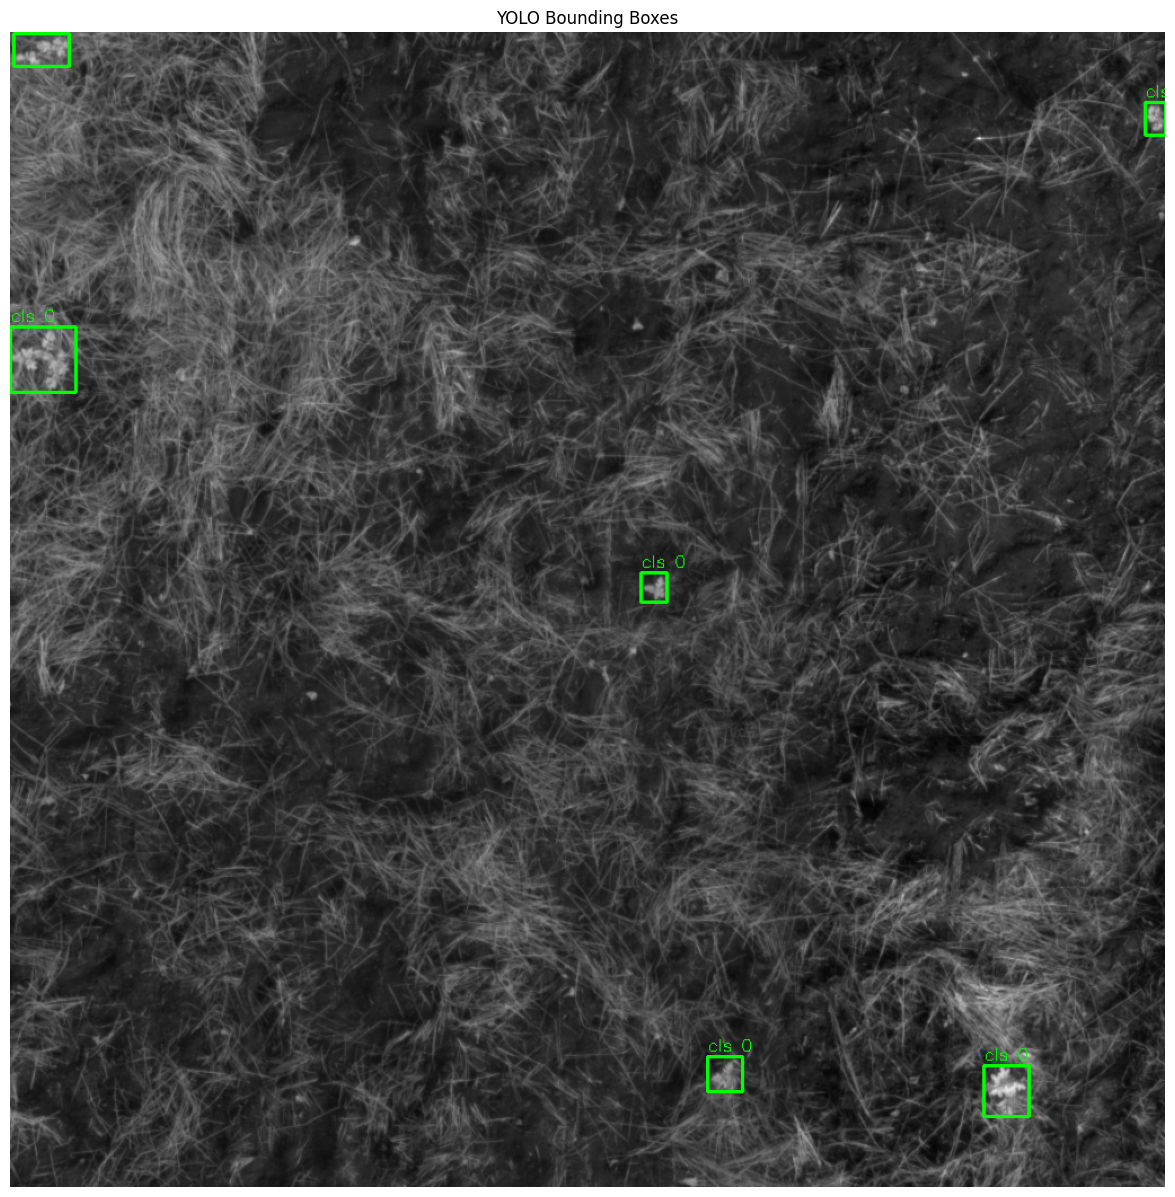

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import rasterio
# ------------------------------
# Paths
# ------------------------------
image_path = "/home/samuel/test/MasterThesis/Orthomosaics/translated/small/translated_n18x/processed_output/nir/tile_12_NIR.png"
label_path = "/home/samuel/test/MasterThesis/Orthomosaics/translated/small/translated_n18x/labels_txt/tile_12.txt"

# ------------------------------
# Load image
# ------------------------------
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# ------------------------------
# Load YOLO labels and draw boxes
# ------------------------------
with open(label_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        cls = int(parts[0])

        x_c, y_c, bw, bh = map(float, parts[1:5])

        # Convert normalized → pixel coordinates
        x_c *= w
        y_c *= h
        bw *= w
        bh *= h

        x1 = int(x_c - bw / 2)
        y1 = int(y_c - bh / 2)
        x2 = int(x_c + bw / 2)
        y2 = int(y_c + bh / 2)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Optional: draw class label
        cv2.putText(
            img,
            f"cls {cls}",
            (x1, max(y1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

# ------------------------------
# Show result
# ------------------------------
plt.figure(figsize=(15, 15))
plt.imshow(img)
plt.title("YOLO Bounding Boxes")
plt.axis("off")
plt.show()
